In [1]:
#1.IMPORT LIBRARIES
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

In [2]:
#2.Define Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)
#     return device

Using device: cpu


In [3]:
#2.LOAD DATA
def load_data(train_dir, test_dir):

    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])

    train_data = datasets.ImageFolder(train_dir, transform=transform)
    test_data = datasets.ImageFolder(test_dir, transform=transform)

    train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_data, batch_size=32, shuffle=False)

    num_classes = len(train_data.classes)

    return train_loader, test_loader, num_classes

In [4]:
#3.FEATURE EXTRACTION
def extract_features(model, loader):

    model.eval()
    features, labels_all = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)

            outputs = model(images)
            outputs = outputs.view(outputs.size(0), -1)

            features.append(outputs.cpu())
            labels_all.append(labels)

    return torch.cat(features), torch.cat(labels_all)

In [5]:
#4.LOAD GOOGLE NET MODEL
def load_googlenet():

    model = models.googlenet(weights=models.GoogLeNet_Weights.IMAGENET1K_V1)

    model.fc = nn.Identity()       # remove classifier
    model.transform_input = False  # IMPORTANT FIX

    model = model.to(device)
    model.eval()

    return model

In [6]:
#5.CLASSIFIER MODEL
class MLFFNN(nn.Module):
    def __init__(self, num_classes):
        super(MLFFNN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [7]:
#6.Train Function (FIXED - WITH ACCURACY)
def train_model(model, X_train, y_train, X_test, y_test, epochs=10):

    train_dataset = TensorDataset(X_train, y_train)
    test_dataset = TensorDataset(X_test, y_test)

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=32)

    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    model = model.to(device)

    loss_history = []
    accuracy_history = []   # NEW

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device).float()
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        loss_history.append(total_loss)

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch = X_batch.to(device).float()
                y_batch = y_batch.to(device)

                outputs = model(X_batch)
                _, predicted = torch.max(outputs, 1)

                correct += (predicted == y_batch).sum().item()
                total += y_batch.size(0)

        accuracy = correct / total
        accuracy_history.append(accuracy)

        print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}, Accuracy: {accuracy:.4f}")

    return model, test_loader, loss_history, accuracy_history

In [8]:
#7.EVALUATION + CONFUSION MATRIX
def evaluate_model(model, test_loader):

    model.eval()
    correct, total = 0, 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device).float()
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)

            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    accuracy = 100 * correct / total
    print("GoogleNet Accuracy:", accuracy)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot()
    plt.title("Confusion Matrix")
    plt.show()

In [9]:
#8.LOSS GRAPH
def plot_loss(loss_history):

    plt.figure()
    plt.plot(loss_history)
    plt.title("Training Loss Curve")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()

Extracting GoogLeNet features...
Epoch 1, Loss: 113.3558, Accuracy: 0.9614
Epoch 2, Loss: 27.0733, Accuracy: 0.9643
Epoch 3, Loss: 15.4665, Accuracy: 0.9714
Epoch 4, Loss: 11.8400, Accuracy: 0.9771
Epoch 5, Loss: 10.2882, Accuracy: 0.9800
Epoch 6, Loss: 9.6422, Accuracy: 0.9814
Epoch 7, Loss: 7.9111, Accuracy: 0.9757
Epoch 8, Loss: 6.8329, Accuracy: 0.9771
Epoch 9, Loss: 6.6105, Accuracy: 0.9757
Epoch 10, Loss: 5.8013, Accuracy: 0.9786
GoogleNet Accuracy: 97.85714285714286


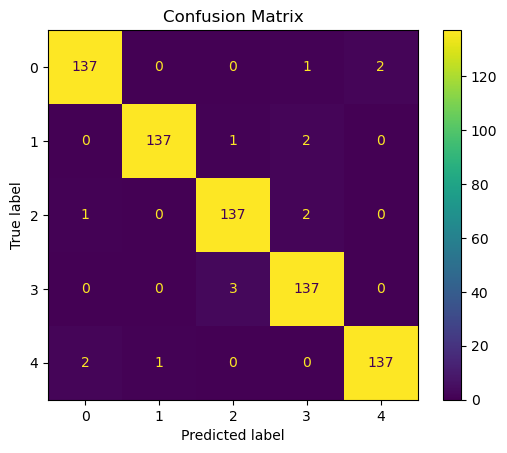

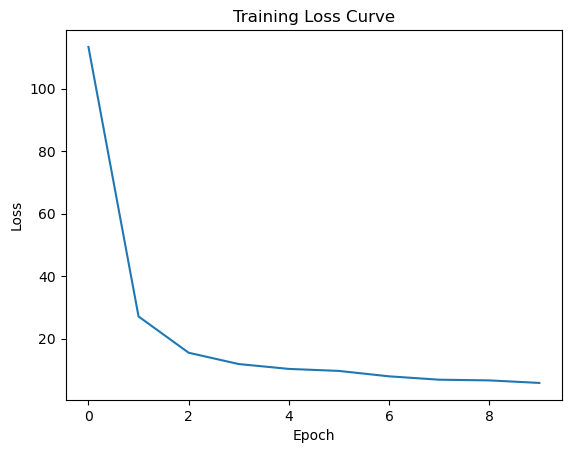

In [12]:
def main():
    
#     device = get_device()

    train_dir = r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\DataSets\Image dataset for classification\train"
    test_dir = r"C:\Users\saima\Desktop\M-Tech\MTech sem 2\DL\Assignments\Assignment 2\DataSets\Image dataset for classification\test"

    # Load data
    train_loader, test_loader, num_classes = load_data(train_dir, test_dir)

    # Load GoogLeNet
    googlenet = load_googlenet()

    # Extract features
    print("Extracting GoogLeNet features...")
    X_train, y_train = extract_features(googlenet, train_loader)
    X_test, y_test = extract_features(googlenet, test_loader)

    # Train classifier
    model = MLFFNN(num_classes)
    model, test_loader, loss_history, accuracy_history = train_model(
    model, X_train, y_train, X_test, y_test
)

    # Evaluate
    evaluate_model(model, test_loader)

    # Plot loss
    plot_loss(loss_history)

    
if __name__ == "__main__":
    main()